<a href="https://colab.research.google.com/github/mohamedsyedjunaith/Coconut-Detection/blob/main/naiveBayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 10 Records
   CGPA  Attendance  Aptitude  Communication  Projects  Placed
0  6.87          96       100             91         3       1
1  9.75          61        97             77         1       1
2  8.66          65        42             89         2       1
3  7.99          73        61             45         3       1
4  5.78          68        45             58         5       1
5  5.78          57        41             99         3       1
6  5.29          80        62             83         3       1
7  9.33          70        83             96         4       1
8  8.01          66        41             50         3       1
9  8.54          72        77             41         5       1

Dataset Shape: (1000, 6)

placement.csv saved successfully.

Training Samples : 800
Testing Samples  : 200

Model Training Completed

Accuracy : 100.0 %

Confusion Matrix
[[200]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


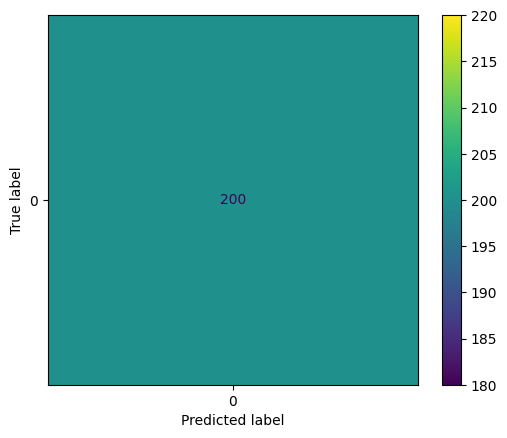


Classification Report

              precision    recall  f1-score   support

           1       1.00      1.00      1.00       200

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200


Prediction
Placed

Probability
Not Placed : 100.0 %


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


IndexError: index 1 is out of bounds for axis 0 with size 1

In [1]:
# ============================================================
# STUDENT PLACEMENT PREDICTION USING NAIVE BAYES
# Google Colab Project
# ============================================================

# -----------------------------
# STEP 1 : Import Libraries
# -----------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# -----------------------------
# STEP 2 : Generate Dataset
# -----------------------------

np.random.seed(42)

num_students = 1000

cgpa = np.round(np.random.uniform(5.0, 10.0, num_students), 2)
attendance = np.random.randint(50, 101, num_students)
aptitude = np.random.randint(40, 101, num_students)
communication = np.random.randint(40, 101, num_students)
projects = np.random.randint(0, 6, num_students)

placed = []

for i in range(num_students):

    score = (
        cgpa[i] * 10 +
        attendance[i] * 0.20 +
        aptitude[i] * 0.35 +
        communication[i] * 0.25 +
        projects[i] * 5
    )

    if score >= 95:
        placed.append(1)
    else:
        placed.append(0)

df = pd.DataFrame({
    "CGPA": cgpa,
    "Attendance": attendance,
    "Aptitude": aptitude,
    "Communication": communication,
    "Projects": projects,
    "Placed": placed
})

print("First 10 Records")
print(df.head(10))

print("\nDataset Shape:", df.shape)

# -----------------------------
# STEP 3 : Save Dataset
# -----------------------------

df.to_csv("placement.csv", index=False)

print("\nplacement.csv saved successfully.")

# -----------------------------
# STEP 4 : Features & Target
# -----------------------------

X = df.drop("Placed", axis=1)
y = df["Placed"]

# -----------------------------
# STEP 5 : Train-Test Split
# -----------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining Samples :", len(X_train))
print("Testing Samples  :", len(X_test))

# -----------------------------
# STEP 6 : Train Naive Bayes
# -----------------------------

model = GaussianNB()

model.fit(X_train, y_train)

print("\nModel Training Completed")

# -----------------------------
# STEP 7 : Prediction
# -----------------------------

y_pred = model.predict(X_test)

# -----------------------------
# STEP 8 : Accuracy
# -----------------------------

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy :", round(accuracy * 100, 2), "%")

# -----------------------------
# STEP 9 : Confusion Matrix
# -----------------------------

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix")
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.show()

# -----------------------------
# STEP 10 : Classification Report
# -----------------------------

print("\nClassification Report\n")

print(classification_report(y_test, y_pred))

# -----------------------------
# STEP 11 : Predict New Student
# -----------------------------

new_student = [[
    8.8,
    92,
    91,
    90,
    4
]]

prediction = model.predict(new_student)

probability = model.predict_proba(new_student)

print("\nPrediction")

if prediction[0] == 1:
    print("Placed")
else:
    print("Not Placed")

print("\nProbability")

print("Not Placed :", round(probability[0][0]*100,2),"%")
print("Placed     :", round(probability[0][1]*100,2),"%")

# -----------------------------
# STEP 12 : Scatter Plot
# -----------------------------

plt.figure(figsize=(7,5))

plt.scatter(
    df["CGPA"],
    df["Aptitude"],
    c=df["Placed"]
)

plt.xlabel("CGPA")
plt.ylabel("Aptitude Score")
plt.title("Student Placement Dataset")

plt.show()

# -----------------------------
# STEP 13 : Feature Statistics
# -----------------------------

print("\nDataset Summary")

print(df.describe())

# -----------------------------
# STEP 14 : Count Placed Students
# -----------------------------

print("\nPlacement Count")

print(df["Placed"].value_counts())

plt.figure(figsize=(5,4))

df["Placed"].value_counts().plot(kind="bar")

plt.title("Placement Distribution")

plt.xlabel("Placed")

plt.ylabel("Number of Students")

plt.show()

# ============================================================
# END OF PROJECT
# ============================================================

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ruchikakumbhar/placement-prediction-dataset")

print("Path to dataset files:", path)

100%|██████████| 99.7k/99.7k [00:00<00:00, 58.1MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/ruchikakumbhar/placement-prediction-dataset/versions/1


In [3]:
import os

print(os.listdir(path))

['placementdata.csv']


In [4]:
import pandas as pd
import os

file = os.path.join(path, os.listdir(path)[0])

df = pd.read_csv(file)

df.head()

,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
0,1,7.5,1,1,1,65,4.4,No,No,61,79,NotPlaced
1,2,8.9,0,3,2,90,4.0,Yes,Yes,78,82,Placed
2,3,7.3,1,2,2,82,4.8,Yes,No,79,80,NotPlaced
3,4,7.5,1,1,2,85,4.4,Yes,Yes,81,80,Placed
4,5,8.3,1,2,2,86,4.5,Yes,Yes,74,88,Placed


In [5]:
df.info()

df.columns

df.head()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StudentID                  10000 non-null  int64  
 1   CGPA                       10000 non-null  float64
 2   Internships                10000 non-null  int64  
 3   Projects                   10000 non-null  int64  
 4   Workshops/Certifications   10000 non-null  int64  
 5   AptitudeTestScore          10000 non-null  int64  
 6   SoftSkillsRating           10000 non-null  float64
 7   ExtracurricularActivities  10000 non-null  object 
 8   PlacementTraining          10000 non-null  object 
 9   SSC_Marks                  10000 non-null  int64  
 10  HSC_Marks                  10000 non-null  int64  
 11  PlacementStatus            10000 non-null  object 
dtypes: float64(2), int64(7), object(3)
memory usage: 937.6+ KB


,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,SSC_Marks,HSC_Marks
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,7.698010,1.049200,2.026600,1.013200,79.449900,4.323960,69.159400,74.501500
std,2886.89568,0.640131,0.665901,0.867968,0.904272,8.159997,0.411622,10.430459,8.919527
min,1.00000,6.500000,0.000000,0.000000,0.000000,60.000000,3.000000,55.000000,57.000000
25%,2500.75000,7.400000,1.000000,1.000000,0.000000,73.000000,4.000000,59.000000,67.000000
50%,5000.50000,7.700000,1.000000,2.000000,1.000000,80.000000,4.400000,70.000000,73.000000
75%,7500.25000,8.200000,1.000000,3.000000,2.000000,87.000000,4.700000,78.000000,83.000000
max,10000.00000,9.100000,2.000000,3.000000,3.000000,90.000000,4.800000,90.000000,88.000000


In [6]:
print(df.columns)

Index(['StudentID', 'CGPA', 'Internships', 'Projects',
       'Workshops/Certifications', 'AptitudeTestScore', 'SoftSkillsRating',
       'ExtracurricularActivities', 'PlacementTraining', 'SSC_Marks',
       'HSC_Marks', 'PlacementStatus'],
      dtype='object')


In [7]:
print(df.columns.tolist())

['StudentID', 'CGPA', 'Internships', 'Projects', 'Workshops/Certifications', 'AptitudeTestScore', 'SoftSkillsRating', 'ExtracurricularActivities', 'PlacementTraining', 'SSC_Marks', 'HSC_Marks', 'PlacementStatus']


In [8]:
import pandas as pd
import os

file = os.path.join(path, os.listdir(path)[0])

df = pd.read_csv(file)

df.head()

,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
0,1,7.5,1,1,1,65,4.4,No,No,61,79,NotPlaced
1,2,8.9,0,3,2,90,4.0,Yes,Yes,78,82,Placed
2,3,7.3,1,2,2,82,4.8,Yes,No,79,80,NotPlaced
3,4,7.5,1,1,2,85,4.4,Yes,Yes,81,80,Placed
4,5,8.3,1,2,2,86,4.5,Yes,Yes,74,88,Placed


In [10]:
print(df.shape)

df.info()

df.isnull().sum()

(10000, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StudentID                  10000 non-null  int64  
 1   CGPA                       10000 non-null  float64
 2   Internships                10000 non-null  int64  
 3   Projects                   10000 non-null  int64  
 4   Workshops/Certifications   10000 non-null  int64  
 5   AptitudeTestScore          10000 non-null  int64  
 6   SoftSkillsRating           10000 non-null  float64
 7   ExtracurricularActivities  10000 non-null  object 
 8   PlacementTraining          10000 non-null  object 
 9   SSC_Marks                  10000 non-null  int64  
 10  HSC_Marks                  10000 non-null  int64  
 11  PlacementStatus            10000 non-null  object 
dtypes: float64(2), int64(7), object(3)
memory usage: 937.6+ KB


,0
StudentID,0
CGPA,0
Internships,0
Projects,0
Workshops/Certifications,0
AptitudeTestScore,0
SoftSkillsRating,0
ExtracurricularActivities,0
PlacementTraining,0
SSC_Marks,0


In [12]:
df.drop("StudentID", axis=1, inplace=True)

KeyError: "['StudentID'] not found in axis"

In [13]:
print(df.columns.tolist())

['CGPA', 'Internships', 'Projects', 'Workshops/Certifications', 'AptitudeTestScore', 'SoftSkillsRating', 'ExtracurricularActivities', 'PlacementTraining', 'SSC_Marks', 'HSC_Marks', 'PlacementStatus']


In [15]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["ExtracurricularActivities"] = encoder.fit_transform(df["ExtracurricularActivities"])

df["PlacementTraining"] = encoder.fit_transform(df["PlacementTraining"])

df["PlacementStatus"] = encoder.fit_transform(df["PlacementStatus"])

In [16]:
print(df["PlacementStatus"].value_counts())

PlacementStatus
0    5803
1    4197
Name: count, dtype: int64


In [17]:
X = df.drop("PlacementStatus", axis=1)

y = df["PlacementStatus"]

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [19]:
from sklearn.naive_bayes import GaussianNB

model = GaussianNB()

model.fit(X_train, y_train)

GaussianNB()

In [20]:
y_pred = model.predict(X_test)

In [21]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", round(accuracy*100,2),"%")

Accuracy : 79.35 %


In [22]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[925 247]
 [166 662]]


In [23]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.79      0.82      1172
           1       0.73      0.80      0.76       828

    accuracy                           0.79      2000
   macro avg       0.79      0.79      0.79      2000
weighted avg       0.80      0.79      0.79      2000



In [24]:
student = pd.DataFrame({
    "CGPA":[8.5],
    "Internships":[2],
    "Projects":[4],
    "Workshops/Certifications":[3],
    "AptitudeTestScore":[82],
    "SoftSkillsRating":[4],
    "ExtracurricularActivities":[1],   # Yes
    "PlacementTraining":[1],           # Yes
    "SSC_Marks":[88],
    "HSC_Marks":[85]
})

prediction = model.predict(student)
probability = model.predict_proba(student)

if prediction[0] == 1:
    print("Prediction : Placed")
else:
    print("Prediction : Not Placed")

print("\nProbability")
print("Not Placed :", round(probability[0][0]*100,2),"%")
print("Placed     :", round(probability[0][1]*100,2),"%")

Prediction : Placed

Probability
Not Placed : 0.0 %
Placed     : 100.0 %
